In [ ]:
import logging
import os
import warnings
from contextlib import redirect_stderr, redirect_stdout
from io import BytesIO, StringIO
from tempfile import gettempdir

# This notebook does not use GPU computation. Molab can expose an unusable
# CUDA plugin, so keep JAX on CPU before importing the HSSM stack.
os.environ["JAX_PLATFORMS"] = "cpu"
os.environ["JAX_SKIP_CUDA_CONSTRAINTS_CHECK"] = "1"
os.environ.setdefault("MPLCONFIGDIR", f"{gettempdir()}/hssm-link-matplotlib")

warnings.filterwarnings("ignore")
logging.getLogger("jax._src.xla_bridge").setLevel(logging.CRITICAL)
logging.getLogger("matplotlib").setLevel(logging.ERROR)

import bambi as bmb
import marimo as mo
import numpy as np
import pandas as pd
import pytensor.tensor as pt

with redirect_stderr(StringIO()):
    import matplotlib.pyplot as plt

import hssm

logging.getLogger("hssm").setLevel(logging.ERROR)
hssm.set_floatX("float64")
pd.set_option("display.max_colwidth", 80)

In [ ]:
mo.md(f"""
# Understanding link functions in HSSM

A link function is the bridge between an ordinary regression and a model
parameter that may be positive, bounded, or otherwise constrained. This
tutorial starts from that idea and then shows how links determine the scale
on which HSSM interprets regression coefficients and chooses safe priors.

The examples use **HSSM {hssm.__version__}** and **Bambi {bmb.__version__}**.
They only construct models and inspect their structure; no MCMC is needed.

By the end, you should be able to answer three questions:

1. What does a link do to a linear predictor?
2. When should an HSSM parameter use identity, log, or generalized logit?
3. Why do HSSM's safe intercept priors depend on the effective link?
""")

# Understanding link functions in HSSM

A link function is the bridge between an ordinary regression and a model
parameter that may be positive, bounded, or otherwise constrained. This
tutorial starts from that idea and then shows how links determine the scale
on which HSSM interprets regression coefficients and chooses safe priors.

The examples use **HSSM 0.4.0** and **Bambi 0.20.0**.
They only construct models and inspect their structure; no MCMC is needed.

By the end, you should be able to answer three questions:

1. What does a link do to a linear predictor?
2. When should an HSSM parameter use identity, log, or generalized logit?
3. Why do HSSM's safe intercept priors depend on the effective link?

## 1. A regression produces an unconstrained linear predictor

For a predictor `x`, a simple regression first constructs

$$\eta_i = \beta_0 + \beta_1 x_i.$$

The number $\eta_i$ can be anywhere on the real line. That is fine for an
unbounded parameter such as drift rate $v$, but it can be invalid for a
boundary separation $a>0$ or a starting-point fraction $0<z<1$.

A link $g$ connects the parameter scale to the predictor scale. HSSM uses
the inverse link when building the model:

$$\theta_i = g^{-1}(\eta_i).$$

The regression coefficients live on the **linear-predictor scale**. The
inverse link turns their result into a valid value on the **parameter scale**.

In [ ]:
parameter_support_table = pd.DataFrame(
    [
        {
            "DDM parameter": "v (drift rate)",
            "support": "(-inf, inf)",
            "support-respecting link": "identity",
            "inverse link": "v = eta",
        },
        {
            "DDM parameter": "a (boundary separation)",
            "support": "(0, inf)",
            "support-respecting link": "log",
            "inverse link": "a = exp(eta)",
        },
        {
            "DDM parameter": "z (starting-point fraction)",
            "support": "(0, 1)",
            "support-respecting link": "generalized logit",
            "inverse link": "z = 1 / (1 + exp(-eta))",
        },
    ]
)
parameter_support_table

,DDM parameter,support,support-respecting link,inverse link
0,v (drift rate),"(-inf, inf)",identity,v = eta
1,a (boundary separation),"(0, inf)",log,a = exp(eta)
2,z (starting-point fraction),"(0, 1)",generalized logit,z = 1 / (1 + exp(-eta))



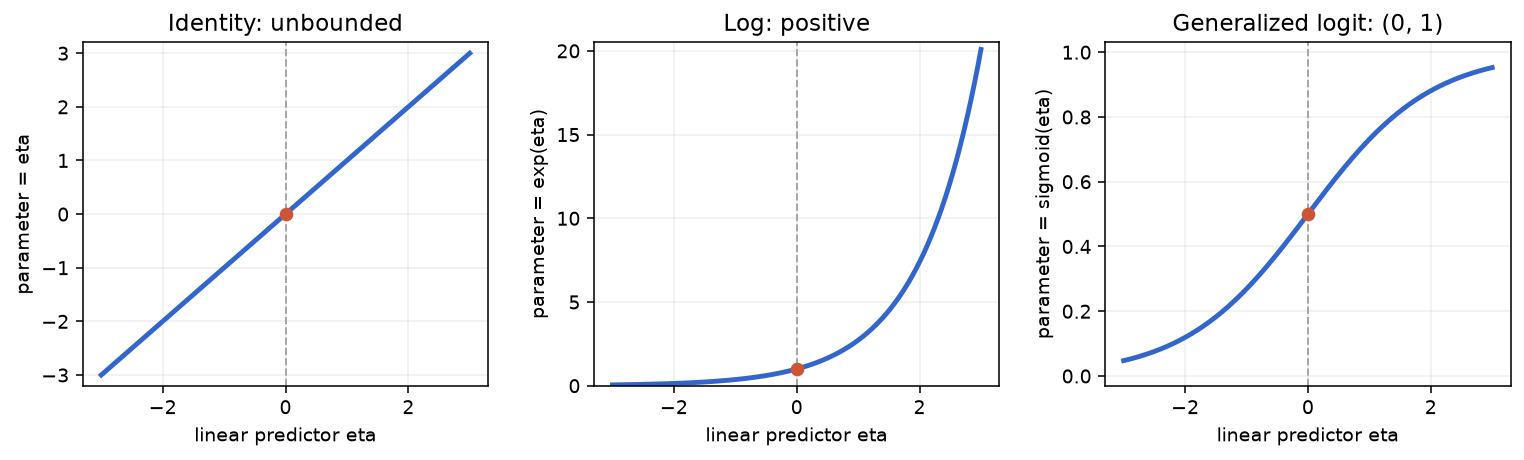

In [ ]:
eta_grid = np.linspace(-3.0, 3.0, 301)
link_curves_figure, _axes = plt.subplots(1, 3, figsize=(11, 3.4))
_curves = [
    ("Identity: unbounded", eta_grid, (-3.2, 3.2), "parameter = eta"),
    ("Log: positive", np.exp(eta_grid), (0.0, 20.5), "parameter = exp(eta)"),
    (
        "Generalized logit: (0, 1)",
        1.0 / (1.0 + np.exp(-eta_grid)),
        (-0.03, 1.03),
        "parameter = sigmoid(eta)",
    ),
]
for _axis, (_title, _values, _limits, _label) in zip(_axes, _curves, strict=True):
    _axis.plot(eta_grid, _values, color="#3366cc", linewidth=2.5)
    _axis.axvline(0.0, color="0.65", linestyle="--", linewidth=1)
    _axis.scatter([0.0], [_values[len(_values) // 2]], color="#cc5533", zorder=3)
    _axis.set_title(_title)
    _axis.set_xlabel("linear predictor eta")
    _axis.set_ylabel(_label)
    _axis.set_ylim(*_limits)
    _axis.grid(alpha=0.2)
link_curves_figure.tight_layout()
_plot_buffer = BytesIO()
link_curves_figure.savefig(_plot_buffer, format="png", dpi=140, bbox_inches="tight")
link_curves_image = mo.image(
    _plot_buffer.getvalue(),
    alt="Identity, log, and generalized-logit inverse-link curves",
)
link_curves_image

The three panels use the same horizontal predictor scale but different
parameter scales:

- **Identity** leaves the predictor unchanged and does not impose a bound.
- **Log** maps every real predictor to a positive value.
- **Generalized logit** maps every real predictor into finite lower and upper
  bounds. For `(0, 1)`, it is the familiar logistic sigmoid.

Notice the red points at `eta = 0`: identity maps zero to `0`, log maps it to
`1`, and generalized logit maps it to the midpoint `0.5`. This fact matters
when interpreting intercept priors.

In [ ]:
example_x = np.array([-1.0, 0.0, 1.0])
example_eta = 0.2 + 0.5 * example_x
coefficient_example_table = pd.DataFrame(
    {
        "x": example_x,
        "eta = 0.2 + 0.5*x": example_eta,
        "identity parameter": example_eta,
        "positive parameter (log link)": np.exp(example_eta),
        "bounded parameter (0, 1)": 1.0 / (1.0 + np.exp(-example_eta)),
    }
).round(3)
coefficient_example_table

,x,eta = 0.2 + 0.5*x,identity parameter,positive parameter (log link),"bounded parameter (0, 1)"
0,-1.0,-0.3,-0.3,0.741,0.426
1,0.0,0.2,0.2,1.221,0.550
2,1.0,0.7,0.7,2.014,0.668


The coefficients in the table are identical in every column. What changes is
their parameter-scale meaning. The inverse link transforms the **complete**
predictor `0.2 + 0.5*x`; it does not transform the intercept and slope
separately. With a non-identity link, a one-unit change in `x` is additive on
`eta`, not on the final DDM parameter.

In [ ]:
eta_landmarks = np.array([-2.0, 0.0, 2.0])
landmark_table = pd.DataFrame(
    {
        "eta": eta_landmarks,
        "identity": eta_landmarks,
        "log": np.exp(eta_landmarks),
        "generalized logit (0, 1)": 1.0 / (1.0 + np.exp(-eta_landmarks)),
    }
).round(3)
landmark_table

,eta,identity,log,"generalized logit (0, 1)"
0,-2.0,-2.0,0.135,0.119
1,0.0,0.0,1.000,0.500
2,2.0,2.0,7.389,0.881


These three landmarks make the scale change concrete. In the
[Molab notebook](https://molab.marimo.io/github/lnccbrown/HSSM/blob/main/docs/tutorials/link_functions.py),
edit `eta_landmarks` and rerun the cell to explore other values.

## 2. Where the link sits in an HSSM regression

In an HSSM formula such as `a ~ 1 + x`, Bambi constructs the intercept and
slope, combines them into `eta`, and the model family applies the inverse
link before passing trial-wise `a` values to the likelihood.

HSSM exposes two model-level choices for regression parameters:

- `link_settings=None` (the default) uses identity unless a parameter says
  otherwise;
- `link_settings="log_logit"` keeps unbounded parameters on identity, uses
  log for positive parameters, and uses HSSM's generalized logit for
  parameters with finite lower and upper bounds.

You can override the link for an individual regression by adding `"link"`
to that parameter's `include` specification.

In [ ]:
tutorial_data = pd.DataFrame(
    {
        "rt": 0.42 + 0.015 * np.arange(12),
        "response": np.where(np.arange(12) % 2, 1, -1),
        "x": np.linspace(-1.0, 1.0, 12),
    }
)
regression_specs = [
    {"name": _parameter, "formula": f"{_parameter} ~ 1 + x"}
    for _parameter in ("v", "a", "z", "t")
]
model_kwargs = {
    "data": tutorial_data,
    "model": "ddm",
    "loglik_kind": "analytical",
    "include": regression_specs,
    "p_outlier": 0.0,
    "prior_settings": "safe",
    "process_initvals": False,
    "initval_jitter": 0.0,
}

def build_silent_model(**kwargs):
    """Construct an HSSM model without its initialization status message."""
    with redirect_stdout(StringIO()):
        return hssm.HSSM(**kwargs)

tutorial_data.head()

,rt,response,x
0,0.420,-1,-1.000000
1,0.435,1,-0.818182
2,0.450,-1,-0.636364
3,0.465,1,-0.454545
4,0.480,-1,-0.272727


In [ ]:
identity_model = build_silent_model(**model_kwargs, link_settings=None)
transformed_model = build_silent_model(**model_kwargs, link_settings="log_logit")

In [ ]:
def link_name(link):
    """Return a consistent display name for string and object links."""
    return link if isinstance(link, str) else link.name

def inverse_link_value(link, eta):
    """Map one predictor value back to its parameter scale."""
    _link = bmb.Link(link) if isinstance(link, str) else link
    return float(np.asarray(_link.linkinv(eta)))

model_link_table = pd.DataFrame(
    [
        {
            "parameter": _parameter,
            "support": str(identity_model.params[_parameter].bounds),
            "default link": link_name(identity_model.params[_parameter].link),
            "log_logit preset": link_name(
                transformed_model.params[_parameter].link
            ),
            "preset maps eta=0 to": inverse_link_value(
                transformed_model.params[_parameter].link, 0.0
            ),
        }
        for _parameter in ("v", "a", "z", "t")
    ]
)
assert model_link_table.set_index("parameter")["log_logit preset"].to_dict() == {
    "v": "identity",
    "a": "log",
    "z": "gen_logit",
    "t": "log",
}
model_link_table

,parameter,support,default link,log_logit preset,preset maps eta=0 to
0,v,"(-inf, inf)",identity,identity,0.0
1,a,"(0.0, inf)",identity,log,1.0
2,z,"(0.0, 1.0)",identity,gen_logit,0.5
3,t,"(0.0, inf)",identity,log,1.0


For this analytical DDM, the preset follows support rather than parameter names: an unbounded
parameter remains on identity, a lower-bounded positive parameter uses log,
and a parameter with two finite bounds uses generalized logit.

The configured likelihood supplies those bounds. A likelihood with finite
training bounds can therefore resolve a parameter differently—for example,
a finitely bounded neural `v` can receive generalized logit. The preset uses
log only for the exact `(0, inf)` shape; unusual one-sided bounds are left on
identity with a warning. Fixed or otherwise non-regression parameters do not
have a linear predictor and are not assigned links by this preset.

With HSSM's identity default, coefficients keep a direct response-scale
interpretation and safe intercepts can retain HDDM-derived priors. The
`log_logit` preset is an explicit alternative that often gives hierarchical
regressions an unconstrained coefficient space. Neither spelling is
universally preferable; the link is part of the scientific model.

In [ ]:
def format_prior(prior):
    """Format a Bambi prior compactly for a comparison table."""
    return str(prior)

prior_scale_table = pd.DataFrame(
    [
        {
            "parameter": _parameter,
            "identity intercept prior": format_prior(
                identity_model.params[_parameter].prior["Intercept"]
            ),
            "log_logit link": (
                transformed_model.params[_parameter].link
                if isinstance(transformed_model.params[_parameter].link, str)
                else transformed_model.params[_parameter].link.name
            ),
            "log_logit intercept prior": format_prior(
                transformed_model.params[_parameter].prior["Intercept"]
            ),
            "slope prior in both models": format_prior(
                transformed_model.params[_parameter].prior["x"]
            ),
        }
        for _parameter in ("v", "a", "z", "t")
    ]
)

assert identity_model.params["a"].prior["Intercept"].name == "Gamma"
assert identity_model.params["z"].prior["Intercept"].name == "Beta"
assert transformed_model.params["a"].prior["Intercept"].name == "Normal"
assert transformed_model.params["z"].prior["Intercept"].name == "Normal"
assert all(
    format_prior(identity_model.params[_parameter].prior["x"])
    == format_prior(transformed_model.params[_parameter].prior["x"])
    for _parameter in ("v", "a", "z", "t")
)
prior_scale_table

,parameter,identity intercept prior,log_logit link,log_logit intercept prior,slope prior in both models
0,v,"Normal(mu: 2.0, sigma: 3.0)",identity,"Normal(mu: 2.0, sigma: 3.0)","Normal(mu: 0.0, sigma: 0.25)"
1,a,"Gamma(mu: 1.5, sigma: 0.75)",log,"Normal(mu: 0.0, sigma: 0.25)","Normal(mu: 0.0, sigma: 0.25)"
2,z,"Beta(alpha: 10.0, beta: 10.0)",gen_logit,"Normal(mu: 0.0, sigma: 0.25)","Normal(mu: 0.0, sigma: 0.25)"
3,t,"Gamma(mu: 0.2, sigma: 0.2)",log,"Normal(mu: 0.0, sigma: 0.25)","Normal(mu: 0.0, sigma: 0.25)"


## 3. The link determines the scale of a safe intercept prior

This is the core logic behind HSSM's generated `prior_settings="safe"`
defaults:

- With an **identity link**, the intercept is itself a value of the DDM
  parameter. HSSM can therefore use its response-scale HDDM prior, such as a
  positive `Gamma` for `a` or a `(0, 1)` `Beta` for `z` in the analytical
  DDM used here.
- With a **transformed link**, the intercept is an unconstrained coefficient
  inside `eta`. HSSM uses `Normal(0, 0.25)` on that coefficient scale. The
  inverse link then maps it into valid parameter values.
- Ordinary slopes are coefficients on `eta` in either case, so their safe
  default remains `Normal(0, 0.25)`.
- An explicitly supplied prior always takes precedence over a generated
  safe prior.

The HDDM-derived response-scale intercepts shown here apply to analytical
and black-box `ddm`, `ddm_sdv`, and `full_ddm` regressions. Neural
`approx_differentiable` likelihoods use generic safe priors informed by their
configured training bounds. Setting `prior_settings=None` does not remove
priors; it delegates missing regression-term priors to Bambi, while simple
HSSM parameters retain their configured defaults.

For example, `a_Intercept = 0` under a log link means `a = exp(0) = 1`.
It would be a mistake to truncate that coefficient at `a`'s response-scale
lower bound: the transform already enforces positivity.

Conversely, an identity-link prior that keeps the **intercept** inside a
parameter's bounds cannot guarantee that every trial-wise value remains
valid once slopes or group effects are added. A support-respecting link is
the structural way to enforce support on the full predictor.

In [ ]:
identity_link_specs = [
    ("link omitted", None),
    ('link="identity"', "identity"),
    ('bambi.Link("identity")', bmb.Link("identity")),
    ('hssm.Link("identity")', hssm.Link("identity")),
]
_base_kwargs = {
    _key: _value for _key, _value in model_kwargs.items() if _key != "include"
}
_identity_rows = []
for _label, _link in identity_link_specs:
    _a_spec = {"name": "a", "formula": "a ~ 1 + x"}
    if _link is not None:
        _a_spec["link"] = _link
    _model = build_silent_model(**_base_kwargs, include=[_a_spec])
    _identity_rows.append(
        {
            "user spelling": _label,
            "effective link": (
                _model.params["a"].link
                if isinstance(_model.params["a"].link, str)
                else _model.params["a"].link.name
            ),
            "safe a intercept prior": format_prior(
                _model.params["a"].prior["Intercept"]
            ),
        }
    )

identity_equivalence_table = pd.DataFrame(_identity_rows)
assert identity_equivalence_table["effective link"].eq("identity").all()
assert identity_equivalence_table["safe a intercept prior"].nunique() == 1
identity_equivalence_table

,user spelling,effective link,safe a intercept prior
0,link omitted,identity,"Gamma(mu: 1.5, sigma: 0.75)"
1,"link=""identity""",identity,"Gamma(mu: 1.5, sigma: 0.75)"
2,"bambi.Link(""identity"")",identity,"Gamma(mu: 1.5, sigma: 0.75)"
3,"hssm.Link(""identity"")",identity,"Gamma(mu: 1.5, sigma: 0.75)"


The four rows are semantically the same model and now receive the same safe
response-scale prior. HSSM decides from the **effective link**, not from
whether the user happened to omit a value or wrap it in a Link object. This
equivalence is the behavior corrected by
[#1232](https://github.com/lnccbrown/HSSM/issues/1232).

In [ ]:
explicit_intercept_prior = bmb.Prior("StudentT", nu=4.0, mu=1.2, sigma=0.4)
_explicit_base_kwargs = {
    _key: _value for _key, _value in model_kwargs.items() if _key != "include"
}
explicit_prior_model = build_silent_model(
    **_explicit_base_kwargs,
    include=[
        {
            "name": "a",
            "formula": "a ~ 1 + x",
            "prior": {"Intercept": explicit_intercept_prior},
        }
    ],
)
assert (
    explicit_prior_model.params["a"].prior["Intercept"] is explicit_intercept_prior
)
explicit_prior_table = pd.DataFrame(
    [
        {
            "term": "Intercept",
            "source": "explicit user prior",
            "resolved prior": format_prior(
                explicit_prior_model.params["a"].prior["Intercept"]
            ),
        },
        {
            "term": "x",
            "source": "missing term filled by safe settings",
            "resolved prior": format_prior(
                explicit_prior_model.params["a"].prior["x"]
            ),
        },
    ]
)
explicit_prior_table

,term,source,resolved prior
0,Intercept,explicit user prior,"StudentT(nu: 4.0, mu: 1.2, sigma: 0.4)"
1,x,missing term filled by safe settings,"Normal(mu: 0.0, sigma: 0.25)"


`prior_settings="safe"` fills gaps; it does not rewrite the explicit
`StudentT` intercept. Here it supplies only the missing slope prior.

## 4. Built-in links versus custom links

For built-in names such as `"identity"`, `"log"`, and `"logit"`, Bambi
already knows all required numerical and symbolic functions. A custom link
needs three related callables:

1. `link`: numerical parameter-to-predictor mapping;
2. `linkinv`: numerical predictor-to-parameter mapping, used outside the
   PyMC graph for operations such as prediction; and
3. `linkinv_backend`: the symbolic inverse used to build the PyTensor graph.

This is why NumPy functions are appropriate for the first two roles, while
the backend inverse should be written with PyTensor operations.

In [ ]:
custom_log_link = hssm.Link(
    "custom_log",
    link=np.log,
    linkinv=np.exp,
    linkinv_backend=pt.exp,
)
_response_values = np.array([0.5, 1.0, 2.0])
_predictor_values = custom_log_link.link(_response_values)
assert np.allclose(custom_log_link.linkinv(_predictor_values), _response_values)
_symbolic_eta = pt.scalar("tutorial_eta")
_symbolic_parameter = custom_log_link.linkinv_backend(_symbolic_eta)
assert _symbolic_parameter.owner is not None

_custom_base_kwargs = {
    _key: _value for _key, _value in model_kwargs.items() if _key != "include"
}
custom_link_model = build_silent_model(
    **_custom_base_kwargs,
    include=[
        {
            "name": "a",
            "formula": "a ~ 1 + x",
            "link": custom_log_link,
        }
    ],
)
assert custom_link_model.params["a"].link is custom_log_link
assert custom_link_model.model.family.link["a"] is custom_log_link

custom_link_roles = pd.DataFrame(
    [
        {
            "argument": "link=np.log",
            "direction": "parameter -> predictor",
            "execution": "numerical, outside the PyMC graph",
        },
        {
            "argument": "linkinv=np.exp",
            "direction": "predictor -> parameter",
            "execution": "numerical prediction and utilities",
        },
        {
            "argument": "linkinv_backend=pt.exp",
            "direction": "predictor -> parameter",
            "execution": "symbolic, inside the PyMC graph",
        },
    ]
)
custom_link_roles

,argument,direction,execution
0,link=np.log,parameter -> predictor,"numerical, outside the PyMC graph"
1,linkinv=np.exp,predictor -> parameter,numerical prediction and utilities
2,linkinv_backend=pt.exp,predictor -> parameter,"symbolic, inside the PyMC graph"


HSSM's `gen_logit` is the special built-in used for arbitrary finite bounds.
For example, `hssm.Link("gen_logit", bounds=(0.2, 0.8))` maps every real
predictor into `(0.2, 0.8)`.

In [ ]:
link_choice_guide = pd.DataFrame(
    [
        {
            "parameter support": "unbounded",
            "usual choice": "identity",
            "eta=0 means": "parameter=0",
            "main tradeoff": "direct interpretation; no support transform",
        },
        {
            "parameter support": "positive",
            "usual choice": "log",
            "eta=0 means": "parameter=1",
            "main tradeoff": "valid positivity; multiplicative parameter effects",
        },
        {
            "parameter support": "finite (lower, upper)",
            "usual choice": "gen_logit",
            "eta=0 means": "parameter at midpoint",
            "main tradeoff": "valid bounds; nonlinear parameter effects",
        },
    ]
)
link_choice_guide

,parameter support,usual choice,eta=0 means,main tradeoff
0,unbounded,identity,parameter=0,direct interpretation; no support transform
1,positive,log,parameter=1,valid positivity; multiplicative parameter effects
2,"finite (lower, upper)",gen_logit,parameter at midpoint,valid bounds; nonlinear parameter effects


## 5. A practical workflow

1. **Start from support.** Ask whether the parameter is unbounded, positive,
   or bounded on both sides.
2. **Choose an interpretation.** Identity coefficients are additive on the
   parameter scale; transformed coefficients are additive on `eta` and
   nonlinear on the parameter scale.
3. **Inspect the resolved model.** `model.params["a"].link` and
   `model.params["a"].prior` show what HSSM actually built.
4. **Remember the prior scale.** A coefficient prior under a transformed
   link is not a prior directly on the DDM parameter.
5. **Use prior predictive checks.** They reveal the parameter-scale behavior
   implied jointly by the coefficients and inverse link.

An individual override looks like:

```python
model = hssm.HSSM(
    data,
    include=[{"name": "a", "formula": "a ~ 1 + x", "link": "log"}],
    prior_settings="safe",
)
```

Or use `link_settings="log_logit"` to apply the support-aware preset to all
regression parameters at once.

## Takeaway

A link is not merely a numerical guardrail. It determines what regression
coefficients mean, where priors live, and how an unconstrained predictor is
translated into a valid SSM parameter. HSSM therefore treats every semantic
spelling of identity alike, uses response-scale safe intercept priors for
identity, and uses coefficient-scale priors for transformed links.

Continue with:

- the [`hssm.Link` API](https://lnccbrown.github.io/HSSM/api/link/) for supported and custom links;
- [Specify priors and fix parameters](https://lnccbrown.github.io/HSSM/how_to/specify_priors/) for
  explicit prior control;
- [Set initial values](https://lnccbrown.github.io/HSSM/tutorials/initial_values/) for links and initialization;
- [Random-slope prior diagnostics](https://lnccbrown.github.io/HSSM/tutorials/random_slope_safe_priors/) for
  common and group-specific regression terms; and
- [#1225](https://github.com/lnccbrown/HSSM/issues/1225) for the intentionally
  separate policy question around unmatched group-only terms.